# **R/S benchmark — NN validation plots**

Reads the NN models/scaler written by [`04_train_nn.ipynb`](04_train_nn.ipynb) and the stage 1
datasets written by [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb) — makes **no** training
calls, only loads and plots. Three things:

1. predicted vs. true lambda 1 / lambda 2, on the held-out validation split;
2. a spot check — load the model, fix $(R, S)$, sweep $t$, predict; and
3. a KL-divergence check of the NN-predicted GLD against the emulator's own direct fit, at one
   design point — same convention as [`02_train_pce_plot.ipynb`](02_train_pce_plot.ipynb), so the
   two checks can be read side by side: same design point, PCE vs. NN, both against the same real
   data.

Same figure conventions throughout: no titles (captions belong in the LaTeX), configurable
size/fonts/dpi, each saved next to the data it came from.

## 1. Libraries

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
from sklearn.model_selection import train_test_split

from functions import *

/home/casa-wand/Documentos/2024-1_victor_hugo_renata_maria/.venv/lib/python3.11/site-packages/UQpy/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. Config

`n_latent_samples`, `feature_cols`, `target_cols`, `test_frac` and `random_state` must match
[`04_train_nn.ipynb`](04_train_nn.ipynb) — together they name the files being loaded and rebuild the
same held-out validation split.

In [2]:
n_latent_samples = 2500   # must match stage 3/4 — it names the files being loaded

feature_cols = ['r', 's', 'Time (years)']
target_cols  = ['lambda 1', 'lambda 2']

test_frac    = 0.2   # must match stage 4 — rebuilds the same validation split
random_state = 42    # must match stage 4

fig_size   = (5, 4)      # size of each individual figure, in inches
fig_format = 'png'       # format each figure is saved in ('pdf', 'png', ...)
fig_dpi    = 300         # resolution the figure is saved at (dots per inch)

label_fontsize = 14   # font size of the axis labels
tick_fontsize  = 12   # font size of the tick numbers

xlim = None   # e.g. (-5, 5) to fix the axis; None = auto-scaled to the data, per lambda
ylim = None   # e.g. (-5, 5) to fix the axis; None = auto-scaled to the data, per lambda

## 3. Load the stacked dataset and the trained NN

In [3]:
with open(f'{n_latent_samples}_dataset_nn_benchmark.pkl', 'rb') as f:
    df_nn = dill.load(f)

models = {}
for target in target_cols:
    key = target.replace(' ', '_')
    with open(f'{n_latent_samples}_nn_{key}_model_benchmark.pkl', 'rb') as f:
        models[target] = dill.load(f)

with open(f'{n_latent_samples}_nn_scaler_benchmark.pkl', 'rb') as f:
    scaler = dill.load(f)

print(f"Loaded {len(df_nn)} rows and {len(models)} NN models")
df_nn.head()

Loaded 50000 rows and 2 NN models


,r,s,Time (years),lambda 1,lambda 2,lambda 3,lambda 4
0,5.110417,2.274454,0.0,2.837573,5.559482,0.143137,0.130569
1,3.435042,2.304231,0.0,1.133046,6.011376,0.138403,0.133853
2,5.195391,1.842210,0.0,3.354314,6.465245,0.144540,0.125109
3,4.566698,2.544968,0.0,2.023816,5.183452,0.142163,0.135642
4,5.815982,2.080980,0.0,3.736439,5.682511,0.143967,0.125393


## 4. Predicted vs. true, on the held-out validation split

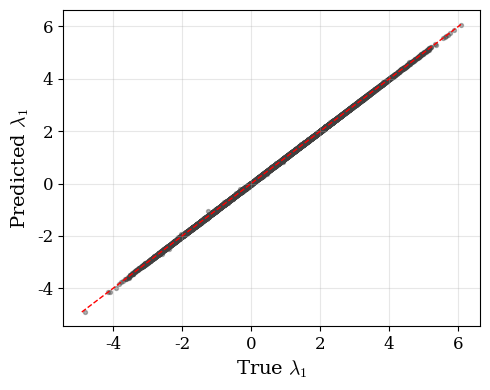

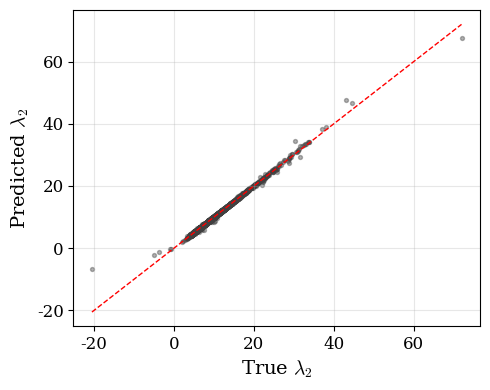

In [4]:
df_clean = df_nn.dropna(subset=target_cols).reset_index(drop=True)
X = df_clean[feature_cols].to_numpy()
y = df_clean[target_cols].to_numpy()
_, x_val, _, y_val = train_test_split(X, y, test_size=test_frac, random_state=random_state)
x_val_s = scaler.transform(x_val)

pkl_name = f'{n_latent_samples}_dataset_nn_benchmark'
figs     = {}

for target in target_cols:
    y_true = y_val[:, target_cols.index(target)]
    y_pred = models[target].predict(x_val_s)
    idx    = target.split(' ')[1]

    fig, ax = plt.subplots(figsize=fig_size)
    ax.scatter(y_true, y_pred, s=8, alpha=0.4, color='0.25')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel(f'True $\lambda_{{{idx}}}$', fontsize=label_fontsize)
    ax.set_ylabel(f'Predicted $\lambda_{{{idx}}}$', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_pred_vs_true_lambda_{idx}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    figs[target] = fig
    plt.show()

## 5. Spot check — load the model, fix $(R, S)$, sweep $t$

Same demo as the exploratory `old/pce_models.ipynb`: fix a design point and sweep $t$, to see the
predicted lambdas evolve smoothly with time.

In [5]:
r_fixed     = 5.0
s_fixed     = 2.0
times_sweep = np.linspace(0, 150, 10, endpoint=True)

sweep_df = pd.DataFrame({
                           'r':            [r_fixed] * len(times_sweep),
                           's':            [s_fixed] * len(times_sweep),
                           'Time (years)': times_sweep,
                        })

x_sweep_s = scaler.transform(sweep_df[feature_cols].to_numpy())
for target in target_cols:
    sweep_df[f'pred_{target}'] = models[target].predict(x_sweep_s)

sweep_df

,r,s,Time (years),pred_lambda 1,pred_lambda 2
0,5.0,2.0,0.000000,2.996175,6.177615
1,5.0,2.0,16.666667,2.422368,6.454737
2,5.0,2.0,33.333333,1.825677,6.649967
3,5.0,2.0,50.000000,1.259414,7.048948
4,5.0,2.0,66.666667,0.665452,7.279433
5,5.0,2.0,83.333333,0.075327,7.690990
6,5.0,2.0,100.000000,-0.505791,7.961829
7,5.0,2.0,116.666667,-1.080565,7.841139
8,5.0,2.0,133.333333,-1.672227,7.438728
9,5.0,2.0,150.000000,-2.253266,7.053496


## 6. NN validation via KL divergence

Spot-checks one design point directly against the NN: the emulator already fits a GLD to its raw
Monte Carlo `g` samples (`lambda 1`-`lambda 4`, in `dataset_unique`/`dataset_full` from
[`01_generate_dataset.ipynb`](01_generate_dataset.ipynb)) — this asks the NN to predict `lambda 1` /
`lambda 2` from `(R, S, t)` alone (`lambda 3`/`lambda 4` are never modelled by the NN, by design —
see [`03_generate_dataset_nn.ipynb`](03_generate_dataset_nn.ipynb)) and scores how close the
resulting GLD is to the real one.

`time_index` and `design_point_index` follow the same convention as
[`02_train_pce_plot.ipynb`](02_train_pce_plot.ipynb) — pick the same values here as there to compare
the PCE and the NN at exactly the same design point.

In [6]:
time_index_kl         = 5   # index into `times_kl` — which stage-1 time step to check
design_point_index_kl = 0   # row index into that time step's dataset_unique_train — which (R, S) to check

times_kl = np.linspace(0, 150, 10, endpoint=True)   # must match stage 1

lambda3_kl = 0.134   # written by hand — the NN never predicts lambda 3 / lambda 4
lambda4_kl = 0.128

n_grid_kl = 400   # grid points used to numerically integrate the KL divergence and R²

xlim_kl = None   # e.g. (-5, 15) to fix the g axis; None = auto-scaled to the data
ylim_kl = None   # e.g. (0, 1) to fix the density axis; None = auto-scaled to the data

In [7]:
t_check = times_kl[time_index_kl]

with open(f'{n_latent_samples}_dataset_full_train_{t_check}_benchmark.pkl', 'rb') as f:
    df_full_check = dill.load(f)
with open(f'{n_latent_samples}_dataset_unique_train_{t_check}_benchmark.pkl', 'rb') as f:
    df_unique_check = dill.load(f)

design_point = df_unique_check.iloc[design_point_index_kl]
r_check, s_check = design_point['r'], design_point['s']
g_real = df_full_check.loc[(df_full_check['r'] == r_check) & (df_full_check['s'] == s_check), 'g'].to_numpy()

print(f"Checking t = {t_check:.2f} years, R = {r_check:.3f}, S = {s_check:.3f} ({len(g_real)} raw g samples)")

kl_result_nn = validate_nn_kl_divergence_benchmark(
                                                      models=models,
                                                      scaler=scaler,
                                                      r=r_check,
                                                      s=s_check,
                                                      t=t_check,
                                                      g_real=g_real,
                                                      lambda3=lambda3_kl,
                                                      lambda4=lambda4_kl,
                                                      n_grid=n_grid_kl,
                                                    )

print(f"KL divergence:  {kl_result_nn['kl_divergence']:.5f}")
print(f"KS statistic:   {kl_result_nn['ks_statistic']:.5f}")
print(f"Wasserstein:    {kl_result_nn['wasserstein']:.5f}")
print(f"R2 (PDFs):      {kl_result_nn['r2_pdf']:.5f}")
print(f"Rel. error P5:  {kl_result_nn['rel_err_p5']:+.2%}")
print(f"Rel. error P50: {kl_result_nn['rel_err_p50']:+.2%}")
print(f"Rel. error P95: {kl_result_nn['rel_err_p95']:+.2%}")

Checking t = 83.33 years, R = 6.203, S = 1.623 (2500 raw g samples)
KL divergence:  0.01023
KS statistic:   0.03800
Wasserstein:    0.01156
R2 (PDFs):      0.97783
Rel. error P5:  +1.33%
Rel. error P50: -0.59%
Rel. error P95: -2.20%


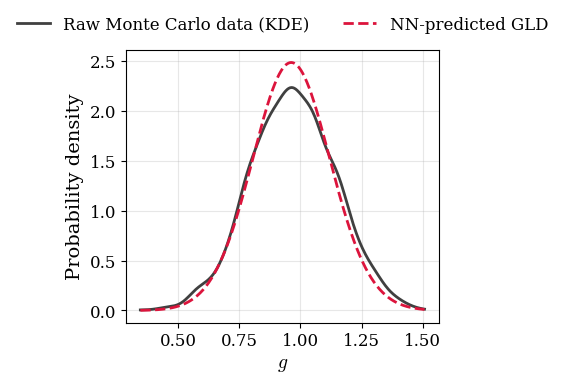

In [8]:
pkl_name_kl = f'{n_latent_samples}_dataset_unique_train_{t_check}_benchmark'

fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_nn['x_grid'], kl_result_nn['pdf_real'], color='0.25', linewidth=2, label='Raw Monte Carlo data (KDE)')
ax.plot(kl_result_nn['x_grid'], kl_result_nn['pdf_nn'], color='crimson', linewidth=2, linestyle='--', label='NN-predicted GLD')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim_kl is not None:
    ax.set_xlim(xlim_kl)
if ylim_kl is not None:
    ax.set_ylim(ylim_kl)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name_kl}_nn_kl_divergence_R{r_check:g}_S{s_check:g}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 6.1 Mesmo gráfico, em português

Para uso na dissertação. Salvo como `<pkl_name>_nn_kl_divergence_R<r>_S<s>_pt.<fig_format>`.

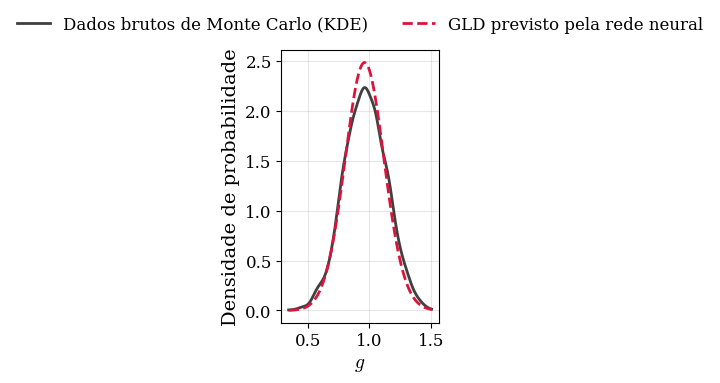

In [9]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_nn['x_grid'], kl_result_nn['pdf_real'], color='0.25', linewidth=2, label='Dados brutos de Monte Carlo (KDE)')
ax.plot(kl_result_nn['x_grid'], kl_result_nn['pdf_nn'], color='crimson', linewidth=2, linestyle='--', label='GLD previsto pela rede neural')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim_kl is not None:
    ax.set_xlim(xlim_kl)
if ylim_kl is not None:
    ax.set_ylim(ylim_kl)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name_kl}_nn_kl_divergence_R{r_check:g}_S{s_check:g}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()